<a href="https://colab.research.google.com/github/wonderalexandre/MTLearn/blob/main/notebooks/experiments/CFP_score_regularization_screws.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CFP score regularization on the screws segmentation dataset

This notebook is a compact regularization example for the CFP API. It trains two independent CFP layers on the same screws segmentation task:

- `task_only`: minimizes only the segmentation loss;
- `edge_regularized`: minimizes the same segmentation loss plus `regularization_penalty(...)` from an `edge_score_monotonicity` regularizer.

The goal is not to produce a benchmark result. The goal is to show where regularization enters the training loop, how it is declared in a filter spec, and how it changes score-violation diagnostics while the target remains a binary segmentation mask.

# Colab instalation

In [3]:
!pip install mtlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.1/977.1 kB 21.9 MB/s eta 0:00:00


## Setup

In [4]:
#!pip install mtlearn

import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

import mtlearn
from mtlearn import morphology
from mtlearn.layers import ConnectedFilterPreprocessingLayer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
generator = torch.Generator(device="cpu").manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
pd.set_option("display.max_columns", 80)

print("device:", device)
print("mtlearn:", mtlearn.__file__)

device: cuda
mtlearn: /usr/local/lib/python3.13/dist-packages/mtlearn/__init__.py


## Experiment Configuration

In [5]:
DATASET_NAME = "screws_segmentation"
NUM_ROWS = 256
NUM_COLS = 256
BATCH_SIZE = 8
OUTPUT_SCALE = 255.0
RESPONSE_THRESHOLD = 0.5
THRESHOLD_GRID = [round(value, 2) for value in np.linspace(0.05, 0.95, 91)]

NUM_EPOCHS = 100
REPORT_EPOCHS = {1, 5, 10, 20, 50, 100}
LEARNING_RATE = 0.01
WEIGHT_DECAY = 1e-7
GRAD_CLIP = 5.0
IDENTITY_P0 = 0.995
SCORE_SHARPNESS = 1.0
CLAMP_LOGIT = 12.0
EDGE_REGULARIZATION_WEIGHT = 0.1
DICE_LOSS_WEIGHT = 0.5
BCE_LOSS_WEIGHT = 0.5
PLOT_SAMPLES = 2

TREE_TYPE = morphology.TreeType.MAX_TREE
ATTRIBUTES = (
    morphology.AttributeType.AREA,
    morphology.AttributeType.LENGTH_MAJOR_AXIS,
    morphology.AttributeType.LENGTH_MINOR_AXIS,
    morphology.AttributeType.INERTIA,
    morphology.AttributeType.CIRCULARITY,
    morphology.AttributeType.GRAY_LEVEL_HEIGHT,
    morphology.AttributeType.RECTANGULARITY,
)

config = {
    "task": "segmentation",
    "dataset": DATASET_NAME,
    "image_size": f"{NUM_ROWS}x{NUM_COLS}",
    "tree_type": TREE_TYPE.name,
    "attributes": [attribute.name for attribute in ATTRIBUTES],
    "regularizer_kind": "edge_score_monotonicity",
    "regularizer_weight": EDGE_REGULARIZATION_WEIGHT,
    "loss": "0.5 * soft_dice + 0.5 * foreground_balanced_bce + regularization_penalty",
    "threshold_selection": "best train F1 over [0.05, 0.95]",
    "fixed_response_threshold": RESPONSE_THRESHOLD,
    "learning_rate": LEARNING_RATE,
    "num_epochs": NUM_EPOCHS,
    "score_sharpness": SCORE_SHARPNESS,
    "identity_p0": IDENTITY_P0,
}
display(pd.DataFrame([config]))

,task,dataset,image_size,tree_type,attributes,regularizer_kind,regularizer_weight,loss,threshold_selection,fixed_response_threshold,learning_rate,num_epochs,score_sharpness,identity_p0
0,segmentation,screws_segmentation,256x256,MAX_TREE,"[AREA, LENGTH_MAJOR_AXIS, LENGTH_MINOR_AXIS, I...",edge_score_monotonicity,0.1,0.5 * soft_dice + 0.5 * foreground_balanced_bc...,"best train F1 over [0.05, 0.95]",0.5,0.01,100,1.0,0.995


## Dataset

screws_segmentation: downloading to /content/dat/screws_segmentation
  downloaded   9% (1.0 MB / 10.5 MB)
  downloaded  19% (2.0 MB / 10.5 MB)
  downloaded  28% (3.0 MB / 10.5 MB)
  downloaded  38% (4.0 MB / 10.5 MB)
  downloaded  47% (5.0 MB / 10.5 MB)
  downloaded  57% (6.0 MB / 10.5 MB)
  downloaded  66% (7.0 MB / 10.5 MB)
  downloaded  76% (8.0 MB / 10.5 MB)
  downloaded  86% (9.0 MB / 10.5 MB)
  downloaded  95% (10.0 MB / 10.5 MB)
  downloaded 100% (10.5 MB / 10.5 MB)
  downloaded 10.5 MB
screws_segmentation: ready at /content/dat/screws_segmentation
trainset: 34
testset: 15
train foreground fraction: 0.0197
positive BCE weight: 49.693


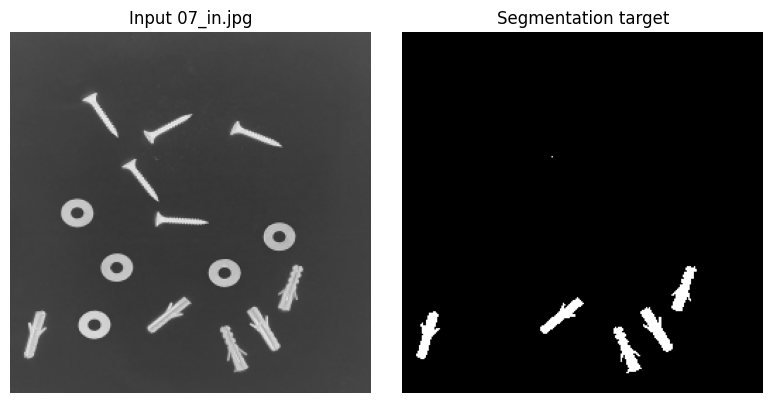

In [6]:
dir_name = str(mtlearn.data.ensure_dataset(DATASET_NAME))
dataset = mtlearn.datasets.PairedImageDataset(
    root_dir=dir_name,
    grayscale_in=True,
    grayscale_target=True,
    invert_in=True,
    invert_target=True,
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    scale_in=True,
    scale_out=True,
    suffix_in="_in",
    suffix_target="_target",
)

trainset, testset = dataset.train_test_split(test_size=0.3, random_state=SEED)
print("trainset:", len(trainset))
print("testset:", len(testset))

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=False,
    generator=generator,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=False,
)

positive_pixels = 0
total_pixels = 0
for _, target, _ in trainset:
    mask = target >= 0.5
    positive_pixels += int(mask.sum().item())
    total_pixels += int(mask.numel())

FOREGROUND_FRACTION = positive_pixels / total_pixels
POSITIVE_BCE_WEIGHT = (total_pixels - positive_pixels) / max(positive_pixels, 1)
print(f"train foreground fraction: {FOREGROUND_FRACTION:.4f}")
print(f"positive BCE weight: {POSITIVE_BCE_WEIGHT:.3f}")

image_in, image_target, name = trainset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_in.squeeze().detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input {name}")
axes[1].imshow(image_target.squeeze().detach().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Segmentation target")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## CFP Layers

In [7]:
def make_filter_spec(name, *, regularizers=None):
    spec = {
        "name": name,
        "tree_type": TREE_TYPE,
        "attributes": ATTRIBUTES,
        "score_sharpness": SCORE_SHARPNESS,
        "scoring": {"kind": "linear_sigmoid"},
    }
    if regularizers is not None:
        spec["regularizers"] = regularizers
    return spec


def make_layer(name, *, regularizers=None):
    return ConnectedFilterPreprocessingLayer(
        in_channels=1,
        filter_specs=[make_filter_spec(name, regularizers=regularizers)],
        scale_mode="dataset_clipped_zscore01",
        device=device,
        clamp=CLAMP_LOGIT,
    )


layers = {
    "task_only": make_layer("task_only"),
    "edge_regularized": make_layer(
        "edge_regularized",
        regularizers=[{"kind": "edge_score_monotonicity", "weight": EDGE_REGULARIZATION_WEIGHT}],
    ),
}

cached_loaders = {}
layer_rows = []
for layer_name, layer in layers.items():
    print(f"Building CFP caches for {layer_name}...")
    train_cached = layer.build_dataloader_cached(trainloader)
    test_cached = layer.build_dataloader_cached_fixed_stats(
        testloader,
        index_offset=len(trainset),
    )
    layer.init_identity(p0=IDENTITY_P0)
    cached_loaders[layer_name] = {"train": train_cached, "test": test_cached}
    spec_config = layer.get_config()["filter_specs"][0]
    layer_rows.append(
        {
            "layer": layer_name,
            "filter_name": spec_config["name"],
            "regularizers": spec_config.get("regularizers", []),
            "parameter_contract": layer.get_parameter_contract(),
        }
    )

display(pd.DataFrame(layer_rows))

Building CFP caches for task_only...
Building CFP caches for edge_regularized...


,layer,filter_name,regularizers,parameter_contract
0,task_only,task_only,[],"{'weights': {'task_only': [7]}, 'biases': {'ta..."
1,edge_regularized,edge_regularized,"[{'kind': 'edge_score_monotonicity', 'weight':...","{'weights': {'edge_regularized': [7]}, 'biases..."


## Evaluation Utilities

In [8]:
def normalize_per_image(batch):
    dims = tuple(range(2, batch.ndim))
    low = batch.amin(dim=dims, keepdim=True)
    high = batch.amax(dim=dims, keepdim=True)
    return (batch - low) / torch.clamp(high - low, min=1e-6)


def cfp_probability(layer, model_input):
    return normalize_per_image(layer(model_input) / OUTPUT_SCALE)


def unpack_model_input(model_input):
    if isinstance(model_input, (tuple, list)):
        return model_input[0], model_input[1]
    return model_input, None


def soft_dice_loss(probabilities, targets, eps=1e-6):
    targets = targets.to(device=probabilities.device, dtype=probabilities.dtype)
    probs = probabilities.reshape(probabilities.size(0), -1)
    masks = targets.reshape(targets.size(0), -1)
    intersection = torch.sum(probs * masks, dim=1)
    denominator = torch.sum(probs, dim=1) + torch.sum(masks, dim=1)
    return (1.0 - (2.0 * intersection + eps) / (denominator + eps)).mean()


def balanced_bce_loss(probabilities, targets):
    targets = targets.to(device=probabilities.device, dtype=probabilities.dtype)
    probabilities = probabilities.clamp(1e-4, 1.0 - 1e-4)
    pixel_loss = F.binary_cross_entropy(probabilities, targets, reduction="none")
    positive_weight = torch.as_tensor(
        POSITIVE_BCE_WEIGHT,
        device=probabilities.device,
        dtype=probabilities.dtype,
    )
    pixel_weight = torch.where(targets >= 0.5, positive_weight, torch.ones_like(targets))
    return torch.mean(pixel_loss * pixel_weight)


def segmentation_loss(probabilities, targets):
    return (
        DICE_LOSS_WEIGHT * soft_dice_loss(probabilities, targets)
        + BCE_LOSS_WEIGHT * balanced_bce_loss(probabilities, targets)
    )


@torch.no_grad()
def edge_violation_sums(layer, model_input):
    x, idx = unpack_model_input(model_input)
    if idx is None:
        raise ValueError("edge_violation_sums expects cached-loader input `(x, idx)`.")

    spec = layer.filter_specs[0]
    totals = {
        "edge_count": 0.0,
        "violation_count": 0.0,
        "violation_sum": 0.0,
        "violation_sq_sum": 0.0,
        "max_violation": 0.0,
    }

    for batch_index in range(x.shape[0]):
        for channel_index in range(x.shape[1]):
            base_key = f"{int(idx[batch_index])}_{channel_index}"
            info, raw_attrs, norm_attrs = layer._get_tree_payload_for_sample(
                base_key,
                x[batch_index, channel_index],
                spec,
                {},
                use_cache=True,
            )
            score_sharpness = layer._score_sharpness_for_spec(spec)
            context = layer._context_for(
                base_key,
                batch_index,
                channel_index,
                spec,
                mode="inspection",
                image_shape=(int(x.shape[-2]), int(x.shape[-1])),
                score_sharpness=score_sharpness,
                raw_attrs=raw_attrs,
                norm_attrs=norm_attrs,
            )
            scores = layer._score_nodes(spec, info, norm_attrs, score_sharpness, context=context)
            parent = info["parent"].to(device=scores.device)
            active = (info["tpost"] > info["tpre"]).to(device=scores.device)
            node_ids = torch.arange(parent.numel(), device=scores.device)
            edge_mask = active & active[parent] & (parent != node_ids)
            if not bool(edge_mask.any().item()):
                continue

            violations = torch.relu(scores[edge_mask] - scores[parent[edge_mask]])
            totals["edge_count"] += float(violations.numel())
            totals["violation_count"] += float((violations > 1e-6).sum())
            totals["violation_sum"] += float(violations.sum())
            totals["violation_sq_sum"] += float(violations.square().sum())
            totals["max_violation"] = max(totals["max_violation"], float(violations.max()))
    return totals


def collect_responses_and_targets(layer, dataloader):
    was_training = layer.training
    layer.eval()
    responses = []
    targets = []
    task_losses = []
    regularization_terms = []
    edge_totals = {
        "edge_count": 0.0,
        "violation_count": 0.0,
        "violation_sum": 0.0,
        "violation_sq_sum": 0.0,
        "max_violation": 0.0,
    }

    with torch.no_grad():
        for model_input, batch_targets in dataloader:
            probabilities = cfp_probability(layer, model_input)
            targets_on_device = batch_targets.to(device=probabilities.device, dtype=probabilities.dtype)
            responses.append(probabilities.detach().cpu())
            targets.append(batch_targets.detach().cpu())
            task_losses.append(float(segmentation_loss(probabilities, targets_on_device).detach().cpu()))
            regularization_terms.append(float(layer.regularization_penalty(model_input).detach().cpu()))

            batch_edges = edge_violation_sums(layer, model_input)
            for key in ("edge_count", "violation_count", "violation_sum", "violation_sq_sum"):
                edge_totals[key] += batch_edges[key]
            edge_totals["max_violation"] = max(edge_totals["max_violation"], batch_edges["max_violation"])

    layer.train(was_training)
    return (
        torch.cat(responses, dim=0),
        torch.cat(targets, dim=0),
        float(np.mean(task_losses)),
        float(np.mean(regularization_terms)),
        edge_totals,
    )


def metrics_from_responses(responses, targets, threshold):
    prediction = responses >= threshold
    target = targets >= 0.5

    tp = torch.sum(prediction & target).item()
    fp = torch.sum(prediction & ~target).item()
    fn = torch.sum(~prediction & target).item()
    tn = torch.sum(~prediction & ~target).item()

    eps = 1e-12
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    return {
        "threshold": float(threshold),
        "iou": tp / (tp + fp + fn + eps),
        "f1": 2.0 * precision * recall / (precision + recall + eps),
        "precision": precision,
        "recall": recall,
        "accuracy": (tp + tn) / (tp + fp + fn + tn + eps),
        "foreground_fraction": (tp + fn) / (tp + fp + fn + tn + eps),
    }


def best_f1_threshold(responses, targets):
    threshold_rows = [
        metrics_from_responses(responses, targets, threshold)
        for threshold in THRESHOLD_GRID
    ]
    return max(threshold_rows, key=lambda row: row["f1"])


def collect_metrics(epoch, layer_name, layer, *, train_objective=None, train_task_loss=None, train_regularization=None):
    train_responses, train_targets, train_eval_loss, train_eval_regularization, train_edges = collect_responses_and_targets(
        layer,
        cached_loaders[layer_name]["train"],
    )
    test_responses, test_targets, test_eval_loss, test_eval_regularization, test_edges = collect_responses_and_targets(
        layer,
        cached_loaders[layer_name]["test"],
    )

    train_best = best_f1_threshold(train_responses, train_targets)
    threshold = train_best["threshold"]
    train_fixed = metrics_from_responses(train_responses, train_targets, RESPONSE_THRESHOLD)
    test_fixed = metrics_from_responses(test_responses, test_targets, RESPONSE_THRESHOLD)
    test_best = metrics_from_responses(test_responses, test_targets, threshold)

    return {
        "epoch": epoch,
        "layer": layer_name,
        "train_objective": train_objective,
        "train_task_loss": train_task_loss,
        "train_regularization": train_regularization,
        "train_eval_loss": train_eval_loss,
        "test_eval_loss": test_eval_loss,
        "train_eval_regularization": train_eval_regularization,
        "test_eval_regularization": test_eval_regularization,
        "threshold": threshold,
        "train_f1_fixed": train_fixed["f1"],
        "test_f1_fixed": test_fixed["f1"],
        "train_iou_fixed": train_fixed["iou"],
        "test_iou_fixed": test_fixed["iou"],
        "train_f1": train_best["f1"],
        "test_f1": test_best["f1"],
        "train_iou": train_best["iou"],
        "test_iou": test_best["iou"],
        "edge_violation_mse_train": train_edges["violation_sq_sum"] / max(train_edges["edge_count"], 1.0),
        "edge_violation_rate_train": train_edges["violation_count"] / max(train_edges["edge_count"], 1.0),
        "max_edge_violation_train": train_edges["max_violation"],
        "edge_violation_mse_test": test_edges["violation_sq_sum"] / max(test_edges["edge_count"], 1.0),
        "edge_violation_rate_test": test_edges["violation_count"] / max(test_edges["edge_count"], 1.0),
        "max_edge_violation_test": test_edges["max_violation"],
    }


def show_segmentation_comparison(epoch, sample_count=PLOT_SAMPLES):
    for layer in layers.values():
        layer.eval()
    batch = next(iter(cached_loaders["task_only"]["test"]))
    model_input, targets = batch
    x, _ = unpack_model_input(model_input)
    n = min(sample_count, x.shape[0])
    fig, axes = plt.subplots(n, 2 + len(layers), figsize=(5 * (2 + len(layers)), 4 * n), squeeze=False)
    fig.suptitle(f"Epoch {epoch}: task-only versus edge-regularized CFP", y=1.02)

    with torch.no_grad():
        predictions = {
            layer_name: cfp_probability(layer, model_input).detach().cpu()
            for layer_name, layer in layers.items()
        }

    for row in range(n):
        axes[row, 0].imshow(x[row, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
        axes[row, 0].set_title("Input")
        axes[row, 1].imshow(targets[row, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Target")
        for col, (layer_name, prediction) in enumerate(predictions.items(), start=2):
            axes[row, col].imshow(prediction[row, 0], cmap="gray", vmin=0, vmax=1)
            axes[row, col].set_title(layer_name)

    for axis in axes.ravel():
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Initial State

,epoch,layer,train_objective,train_task_loss,train_regularization,train_eval_loss,test_eval_loss,train_eval_regularization,test_eval_regularization,threshold,train_f1_fixed,test_f1_fixed,train_iou_fixed,test_iou_fixed,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train,max_edge_violation_train,edge_violation_mse_test,edge_violation_rate_test,max_edge_violation_test
0,0,task_only,None,None,None,0.644602,0.643685,0.0,0.0,0.52,0.484746,0.483060,0.319911,0.318444,0.485323,0.483268,0.320413,0.318625,0.0,0.0,0.0,0.0,0.0,0.0
1,0,edge_regularized,None,None,None,0.644602,0.643685,0.0,0.0,0.52,0.484734,0.483074,0.319900,0.318456,0.485323,0.483268,0.320413,0.318625,0.0,0.0,0.0,0.0,0.0,0.0


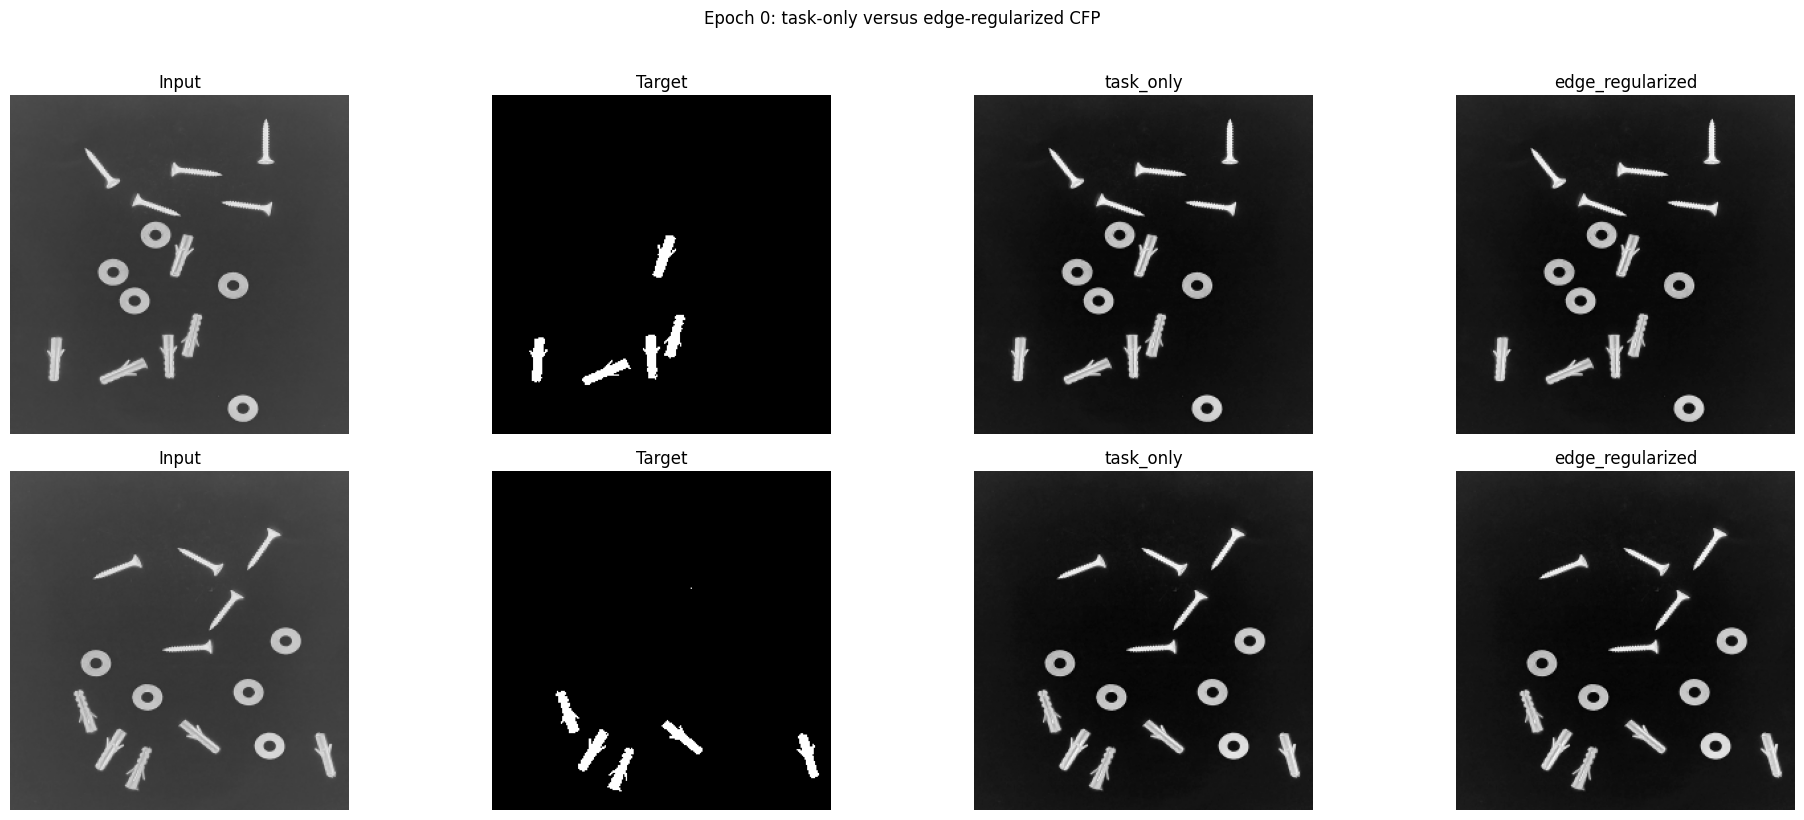

In [9]:
initial_rows = [
    collect_metrics(0, layer_name, layer)
    for layer_name, layer in layers.items()
]
initial_table = pd.DataFrame(initial_rows)
display(initial_table)
show_segmentation_comparison(epoch=0)

## Training

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train
0,1,task_only,0.644585,0.644585,0.000000e+00,0.52,0.485323,0.483268,0.320413,0.318625,6.923702e-08,0.669162
1,1,edge_regularized,0.644585,0.644585,1.504598e-09,0.52,0.485323,0.483268,0.320413,0.318625,6.923519e-08,0.669180


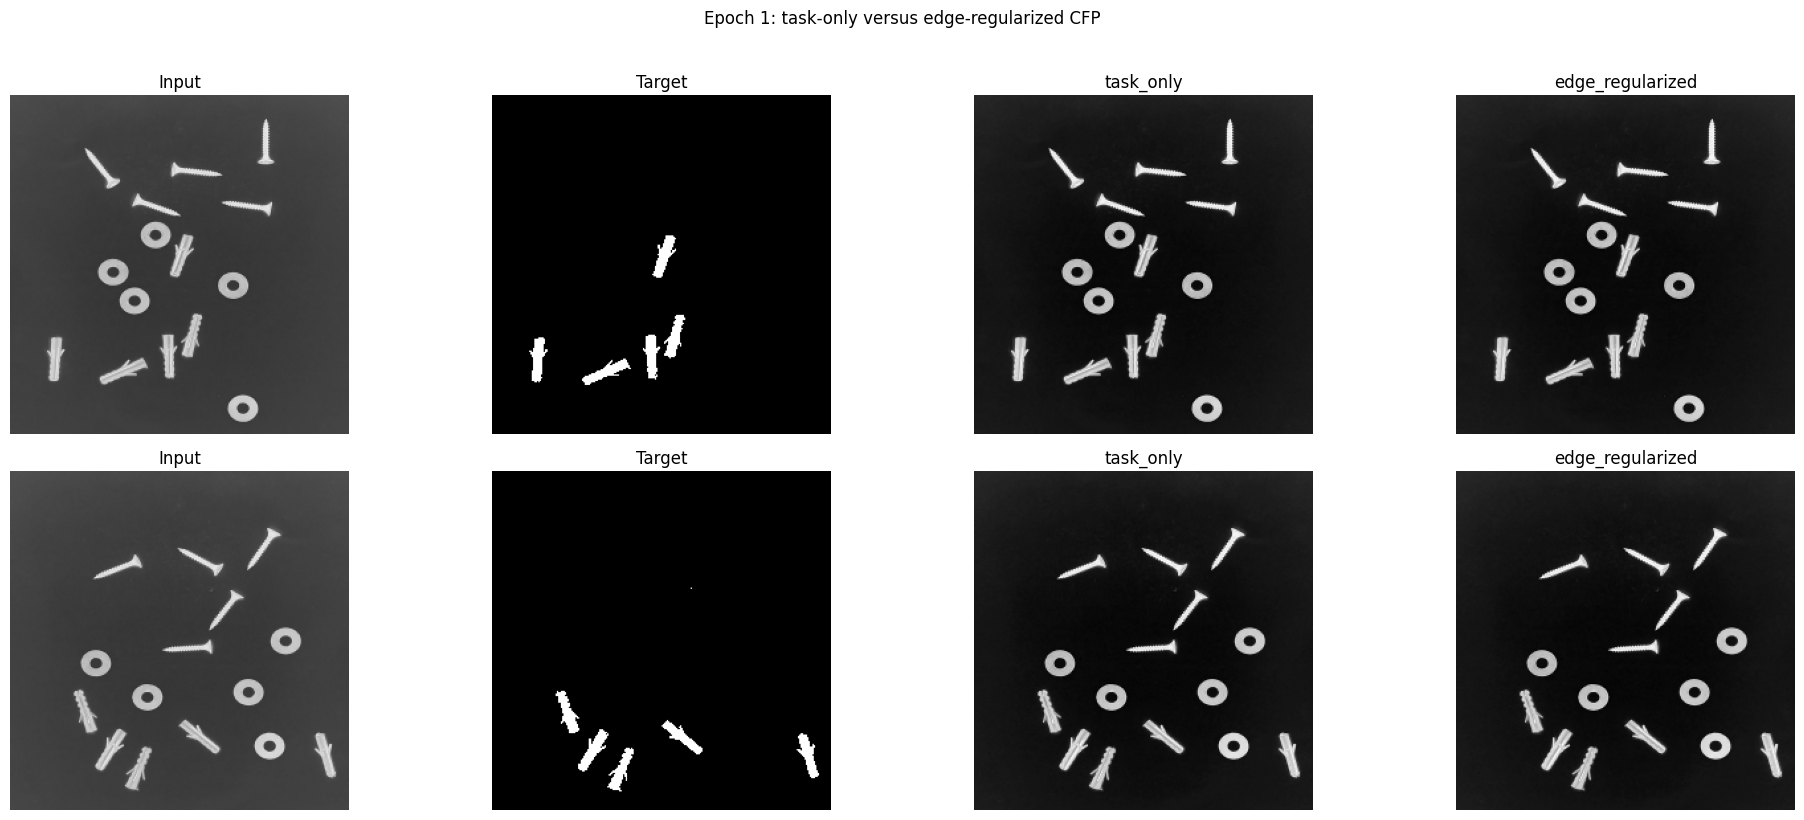

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train
0,5,task_only,0.644189,0.644189,0.000000e+00,0.52,0.485323,0.483268,0.320413,0.318625,0.000019,0.704277
1,5,edge_regularized,0.644191,0.644190,9.975558e-07,0.52,0.485323,0.483268,0.320413,0.318625,0.000019,0.703836


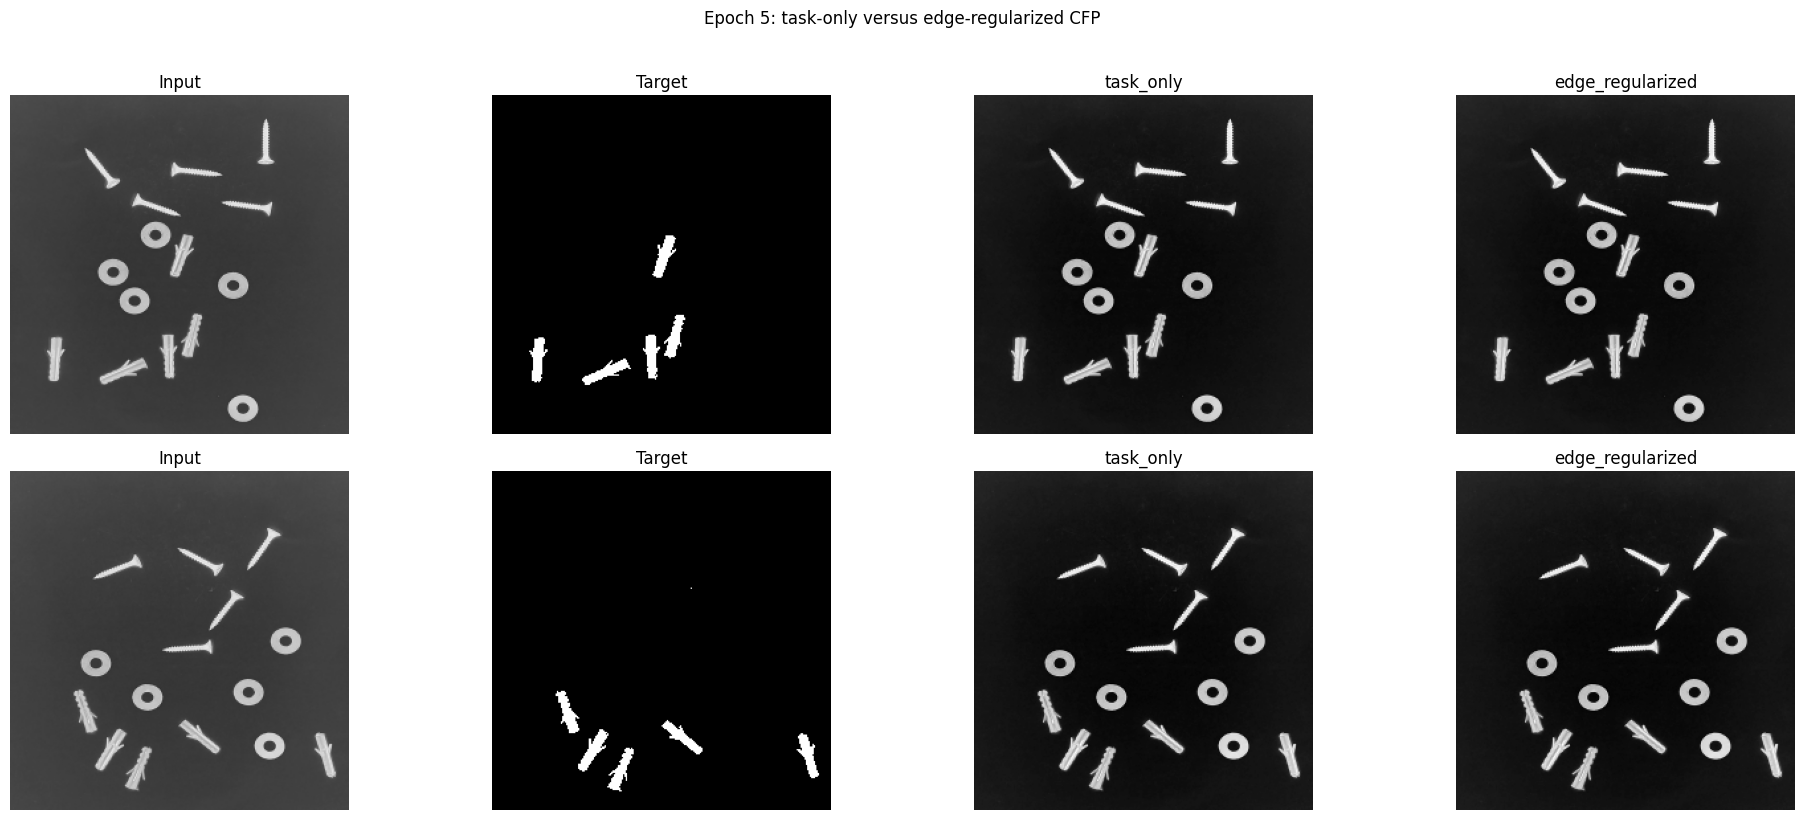

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train
0,10,task_only,0.638471,0.638471,0.000000,0.53,0.485683,0.483683,0.320727,0.318986,0.004994,0.796880
1,10,edge_regularized,0.638765,0.638484,0.000281,0.53,0.485677,0.483683,0.320722,0.318986,0.004969,0.796799


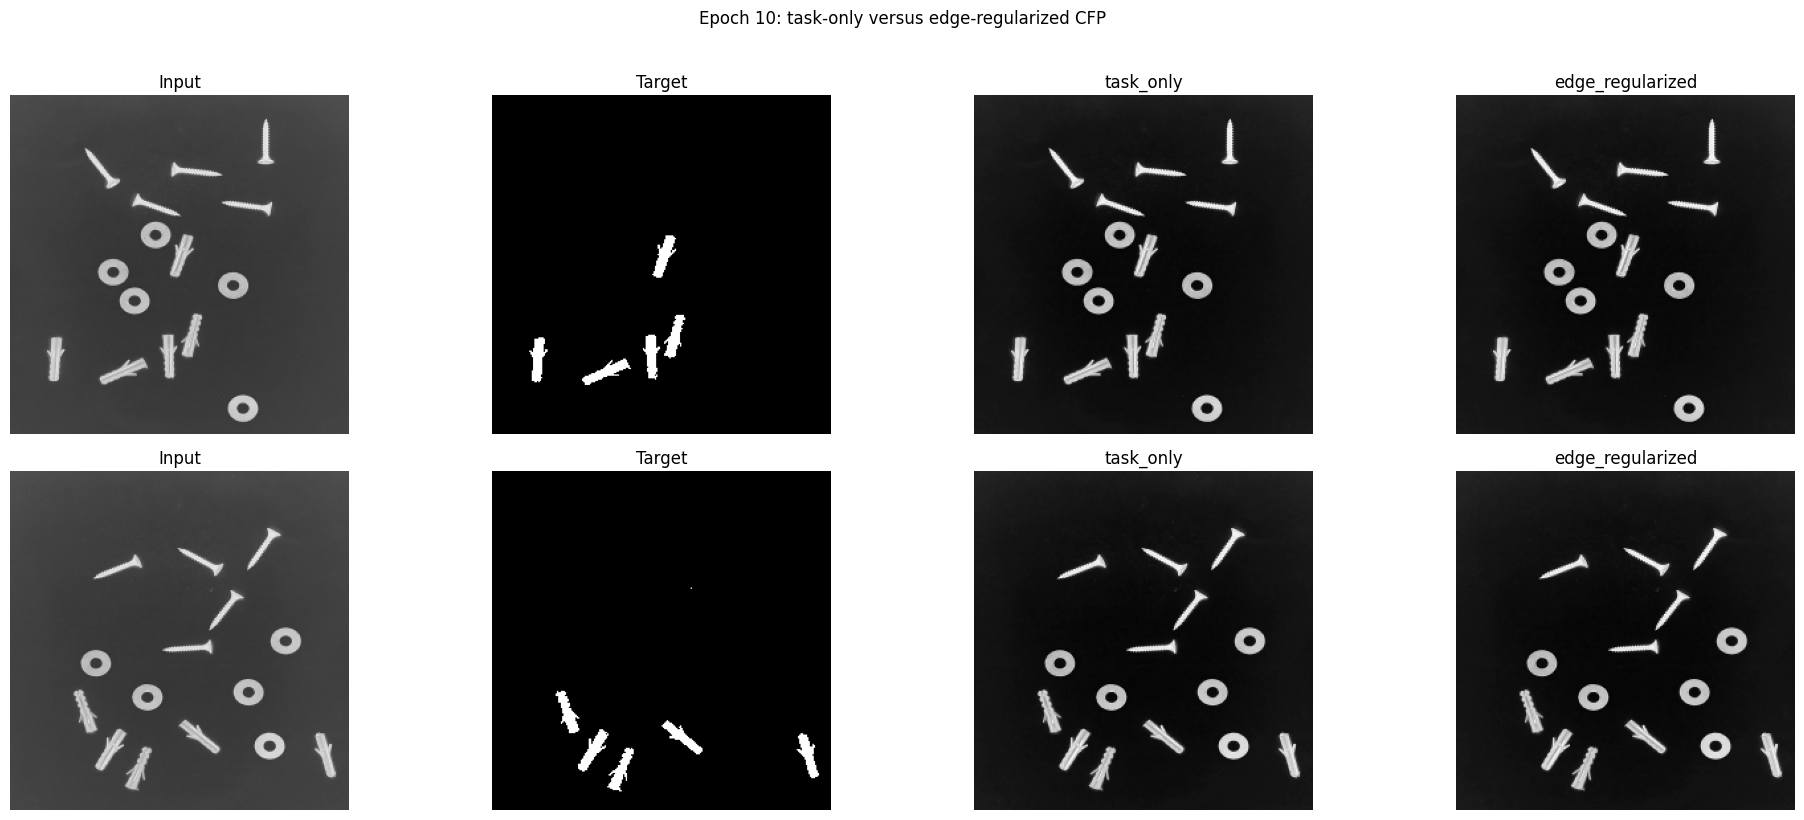

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train
0,20,task_only,0.572313,0.572313,0.000000,0.65,0.605753,0.613535,0.434466,0.442517,0.064483,0.783298
1,20,edge_regularized,0.575569,0.569759,0.005811,0.64,0.621747,0.631426,0.451113,0.461375,0.053226,0.773770


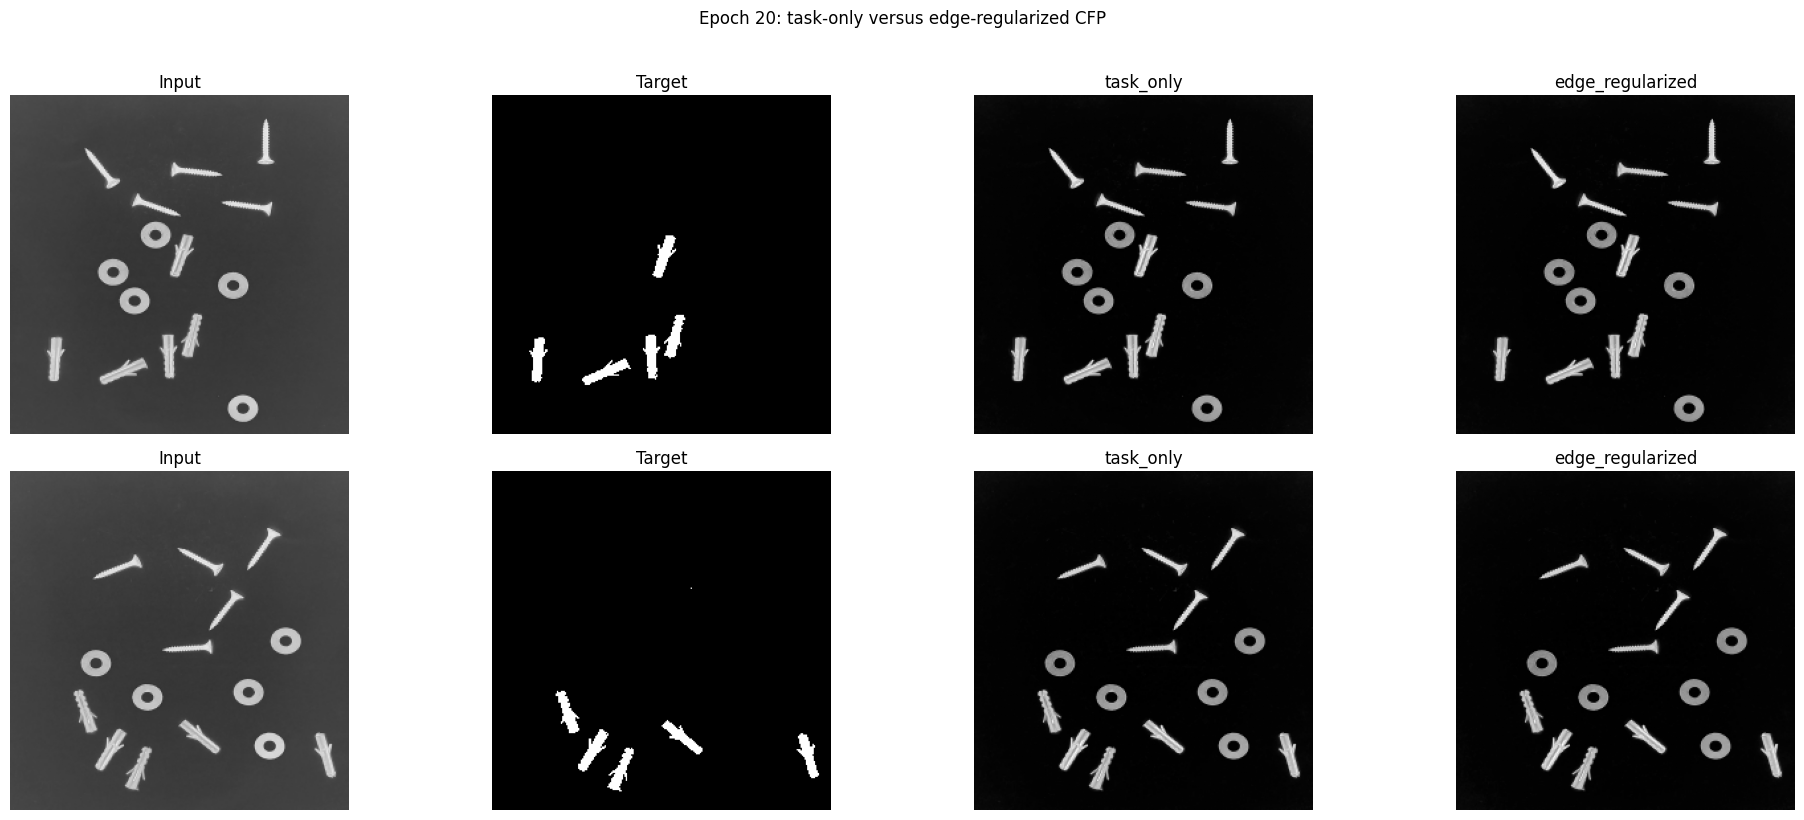

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train
0,50,task_only,0.454690,0.454690,0.000000,0.62,0.703987,0.713665,0.543195,0.554805,0.001862,0.596259
1,50,edge_regularized,0.445232,0.445121,0.000111,0.67,0.713360,0.731309,0.554437,0.576429,0.001046,0.590721


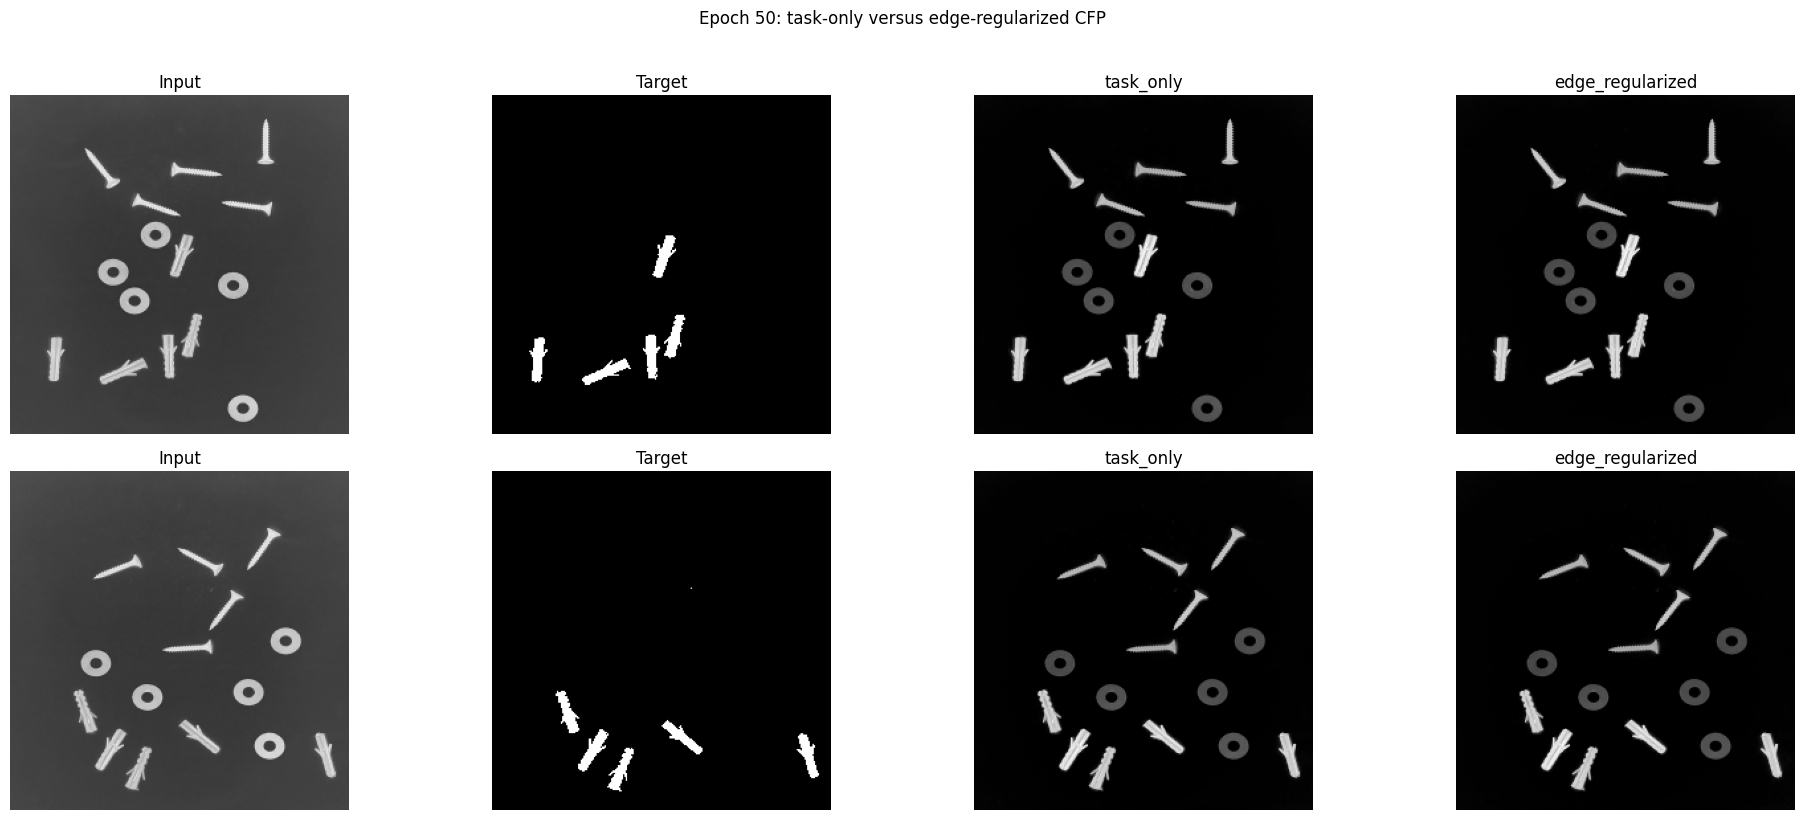

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1,test_f1,train_iou,test_iou,edge_violation_mse_train,edge_violation_rate_train
0,100,task_only,0.365145,0.365145,0.000000,0.73,0.854525,0.867283,0.746001,0.765665,0.000039,0.545261
1,100,edge_regularized,0.361680,0.361677,0.000003,0.74,0.861273,0.871069,0.756348,0.771587,0.000030,0.544280


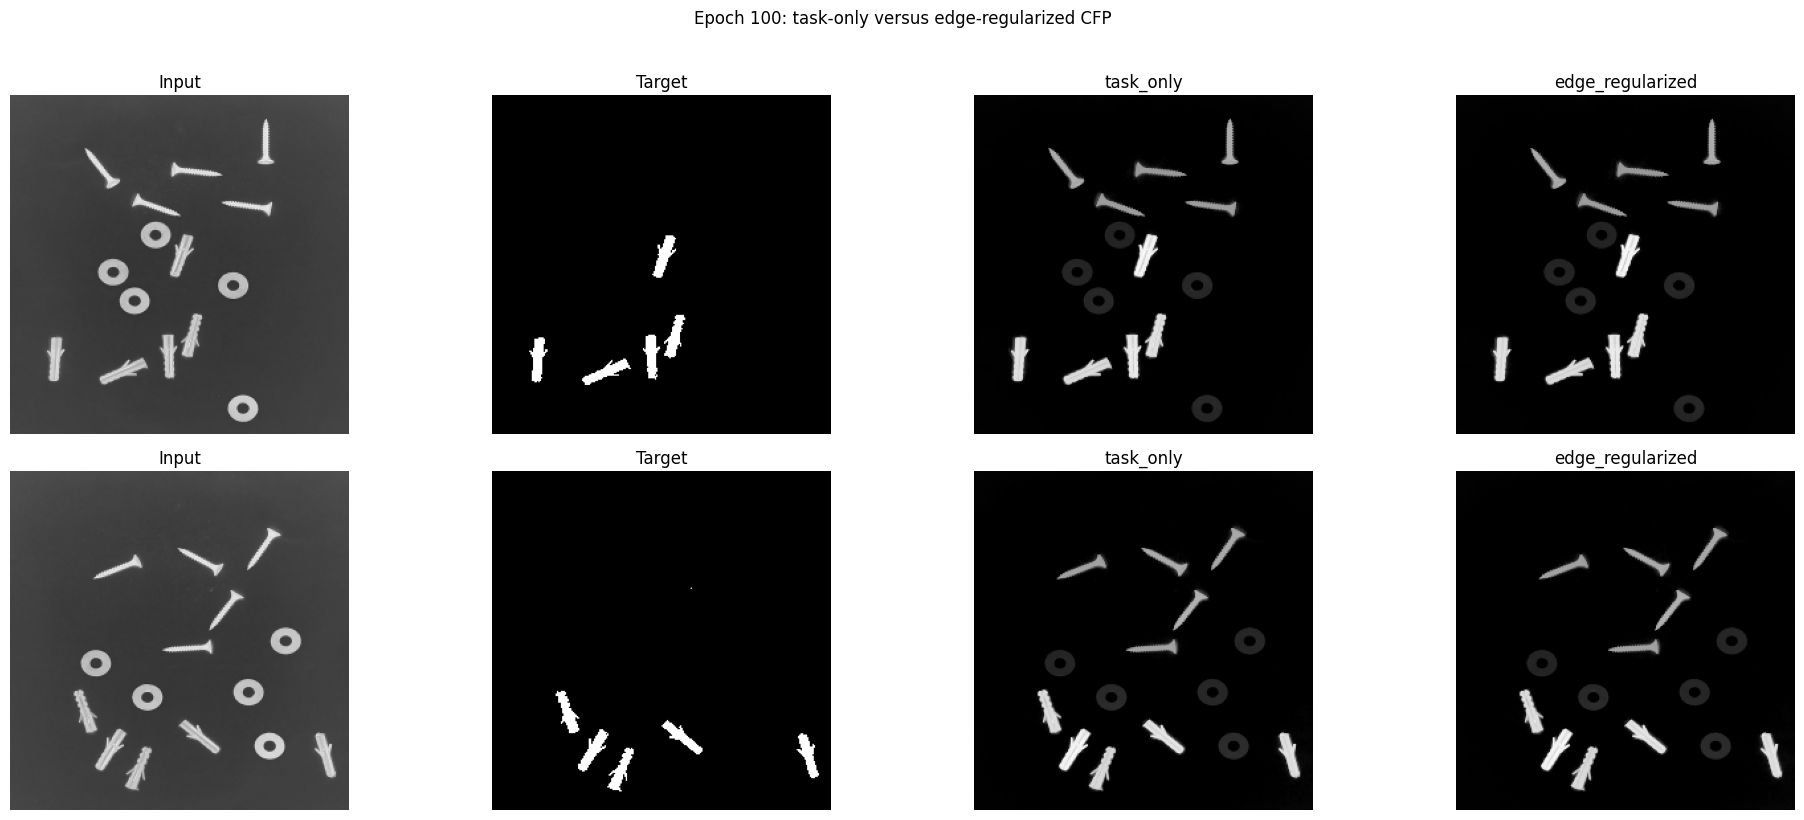

training completed in 2.269 minutes


In [10]:
optimizers = {
    layer_name: torch.optim.Adam(layer.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    for layer_name, layer in layers.items()
}
report_rows = list(initial_rows)
start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = {}

    for layer_name, layer in layers.items():
        layer.train()
        running_objective = 0.0
        running_task_loss = 0.0
        running_regularization = 0.0
        train_cached = cached_loaders[layer_name]["train"]

        for model_input, targets in train_cached:
            probabilities = cfp_probability(layer, model_input)
            targets_on_device = targets.to(device=probabilities.device, dtype=probabilities.dtype)
            task_loss = segmentation_loss(probabilities, targets_on_device)
            regularization_loss = layer.regularization_penalty(model_input)
            loss = task_loss + regularization_loss

            optimizers[layer_name].zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(layer.parameters(), max_norm=GRAD_CLIP)
            optimizers[layer_name].step()

            running_objective += loss.item()
            running_task_loss += task_loss.item()
            running_regularization += regularization_loss.item()

        count = max(len(train_cached), 1)
        epoch_losses[layer_name] = {
            "objective": running_objective / count,
            "task_loss": running_task_loss / count,
            "regularization": running_regularization / count,
        }

    if epoch in REPORT_EPOCHS:
        epoch_rows = [
            collect_metrics(
                epoch,
                layer_name,
                layer,
                train_objective=epoch_losses[layer_name]["objective"],
                train_task_loss=epoch_losses[layer_name]["task_loss"],
                train_regularization=epoch_losses[layer_name]["regularization"],
            )
            for layer_name, layer in layers.items()
        ]
        report_rows.extend(epoch_rows)
        display(
            pd.DataFrame(epoch_rows)[
                [
                    "epoch",
                    "layer",
                    "train_objective",
                    "train_task_loss",
                    "train_regularization",
                    "threshold",
                    "train_f1",
                    "test_f1",
                    "train_iou",
                    "test_iou",
                    "edge_violation_mse_train",
                    "edge_violation_rate_train",
                ]
            ]
        )
        show_segmentation_comparison(epoch=epoch)

elapsed_minutes = (time.time() - start) / 60.0
reports = pd.DataFrame(report_rows)
print(f"training completed in {elapsed_minutes:.3f} minutes")

## Results

,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou,train_eval_loss,test_eval_loss,train_eval_regularization,test_eval_regularization,edge_violation_mse_train,edge_violation_rate_train,max_edge_violation_train,edge_violation_mse_test,edge_violation_rate_test,max_edge_violation_test
1,0,edge_regularized,NaN,NaN,NaN,0.52,0.484734,0.483074,0.485323,0.483268,0.320413,0.318625,0.644602,0.643685,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000
0,0,task_only,NaN,NaN,NaN,0.52,0.484746,0.483060,0.485323,0.483268,0.320413,0.318625,0.644602,0.643685,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000
3,1,edge_regularized,0.644585,0.644585,1.504598e-09,0.52,0.484646,0.483105,0.485323,0.483268,0.320413,0.318625,0.644557,0.643645,6.936033e-09,6.975794e-09,6.923519e-08,0.669180,0.000702,6.982685e-08,0.670069,0.000682
2,1,task_only,0.644585,0.644585,0.000000e+00,0.52,0.484646,0.483105,0.485323,0.483268,0.320413,0.318625,0.644557,0.643645,0.000000e+00,0.000000e+00,6.923702e-08,0.669162,0.000702,6.982796e-08,0.670083,0.000682
5,5,edge_regularized,0.644191,0.644190,9.975558e-07,0.52,0.484810,0.483168,0.485323,0.483268,0.320413,0.318625,0.644045,0.643162,1.944545e-06,1.951543e-06,1.942335e-05,0.703836,0.008937,1.953626e-05,0.703170,0.008664
4,5,task_only,0.644189,0.644189,0.000000e+00,0.52,0.484810,0.483168,0.485323,0.483268,0.320413,0.318625,0.644044,0.643161,0.000000e+00,0.000000e+00,1.949162e-05,0.704277,0.008943,1.960469e-05,0.703750,0.008671
7,10,edge_regularized,0.638765,0.638484,2.809073e-04,0.53,0.485045,0.483276,0.485677,0.483683,0.320722,0.318986,0.636303,0.635354,4.971675e-04,4.986635e-04,4.969191e-03,0.796799,0.130943,4.991950e-03,0.796309,0.129084
6,10,task_only,0.638471,0.638471,0.000000e+00,0.53,0.485045,0.483276,0.485683,0.483683,0.320727,0.318986,0.636282,0.635333,0.000000e+00,0.000000e+00,4.994338e-03,0.796880,0.131271,5.017197e-03,0.796401,0.129408
9,20,edge_regularized,0.575569,0.569759,5.810706e-03,0.64,0.493896,0.491954,0.621747,0.631426,0.451113,0.461375,0.567021,0.555625,5.319732e-03,5.308829e-03,5.322553e-02,0.773770,0.471215,5.315366e-02,0.774826,0.471248
8,20,task_only,0.572313,0.572313,0.000000e+00,0.65,0.492259,0.490758,0.605753,0.613535,0.434466,0.442517,0.570000,0.559880,0.000000e+00,0.000000e+00,6.448328e-02,0.783298,0.505902,6.442280e-02,0.784125,0.505937


Final report


,epoch,layer,train_objective,train_task_loss,train_regularization,threshold,train_f1_fixed,test_f1_fixed,train_f1,test_f1,train_iou,test_iou,train_eval_loss,test_eval_loss,train_eval_regularization,test_eval_regularization,edge_violation_mse_train,edge_violation_rate_train,max_edge_violation_train,edge_violation_mse_test,edge_violation_rate_test,max_edge_violation_test
12,100,task_only,0.365145,0.365145,0.000000,0.73,0.696417,0.707351,0.854525,0.867283,0.746001,0.765665,0.364578,0.348120,0.000000,0.000000,0.000039,0.545261,0.066639,0.000039,0.547162,0.065400
13,100,edge_regularized,0.361680,0.361677,0.000003,0.74,0.696519,0.707472,0.861273,0.871069,0.756348,0.771587,0.361125,0.344447,0.000003,0.000003,0.000030,0.544280,0.060911,0.000030,0.546583,0.059995


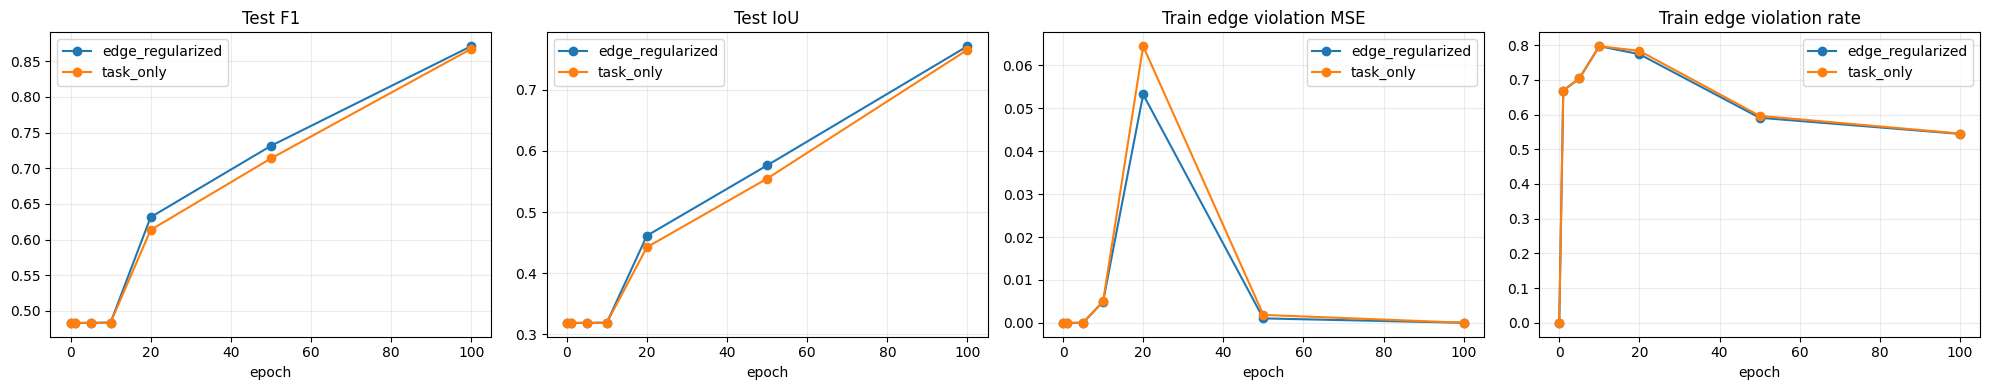

In [11]:
display_columns = [
    "epoch",
    "layer",
    "train_objective",
    "train_task_loss",
    "train_regularization",
    "threshold",
    "train_f1_fixed",
    "test_f1_fixed",
    "train_f1",
    "test_f1",
    "train_iou",
    "test_iou",
    "train_eval_loss",
    "test_eval_loss",
    "train_eval_regularization",
    "test_eval_regularization",
    "edge_violation_mse_train",
    "edge_violation_rate_train",
    "max_edge_violation_train",
    "edge_violation_mse_test",
    "edge_violation_rate_test",
    "max_edge_violation_test",
]
display(reports[display_columns].sort_values(["epoch", "layer"]))

final_rows = reports.sort_values("epoch").groupby("layer", as_index=False).tail(1)
print("Final report")
display(final_rows[display_columns])

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for layer_name, group in reports.groupby("layer"):
    axes[0].plot(group["epoch"], group["test_f1"], marker="o", label=layer_name)
    axes[1].plot(group["epoch"], group["test_iou"], marker="o", label=layer_name)
    axes[2].plot(group["epoch"], group["edge_violation_mse_train"], marker="o", label=layer_name)
    axes[3].plot(group["epoch"], group["edge_violation_rate_train"], marker="o", label=layer_name)

axes[0].set_title("Test F1")
axes[1].set_title("Test IoU")
axes[2].set_title("Train edge violation MSE")
axes[3].set_title("Train edge violation rate")
for axis in axes:
    axis.set_xlabel("epoch")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()